In [ ]:
# import here
import os
import PIL
import pickle
import matplotlib.pyplot as plt
import numpy as np
import random
import cv2
import torch
from torch.utils.data.dataset import Dataset
from torch.utils.data import DataLoader
import torchvision.transforms as transforms
from torchvision.utils import make_grid
import torch.utils.data.sampler as sampler
from torch import nn, optim
import torch.nn.functional as F
import tensorflow as tf
import imgaug.augmenters as iaa
import imgaug as ia

In [2]:
import numpy as np
import time
import mouse
import threading

def move_mouse():
    while True:
        random_row = np.random.random_sample()*100
        random_col = np.random.random_sample()*10
        random_time = np.random.random_sample()*np.random.random_sample() * 100
        mouse.wheel(1000)
        mouse.wheel(-1000)
        mouse.move(random_row, random_col, absolute=False, duration=0.2)
        mouse.move(-random_row, -random_col, absolute=False, duration = 0.2)
        mouse.LEFT
        time.sleep(random_time)


In [ ]:
from google.colab import drive
drive.mount('/content/drive/')

In [ ]:
# Load pickled data
training_pickled = "/content/drive/MyDrive/GTSRB/train.p"

with open(training_pickled, mode='rb') as f:
    train = pickle.load(f)

x_train, y_train = train['features'], train['labels']

sometimes = lambda aug: iaa.Sometimes(0.5, aug)
# Pipeline:
# (1) Crop images from each side by 1-16px, do not resize the results
#     images back to the input size. Keep them at the cropped size.
# (2) Horizontally flip 50% of the images.
# (3) Blur images using a gaussian kernel with sigma between 0.0 and 3.0.
seq = iaa.Sequential(
    [
           
            iaa.OneOf(
                [
                    sometimes(
                                         iaa.imgcorruptlike.GaussianBlur(severity=3)
                             ),
                    
                    sometimes(
                                         iaa.imgcorruptlike.Fog(severity=3)
                             ),
                    
                    sometimes(
                                         iaa.imgcorruptlike.Snow(severity=3)
                             ),
                    
                    sometimes(
                                         iaa.imgcorruptlike.Spatter(severity=3)
                             ),
                    
                    sometimes(
                                         iaa.imgcorruptlike.Contrast(severity=3)
                             ),
                ]
                
            )
                
        ]
        
    )
x_train_aug = seq(images=x_train)  

distorted_train = {
        "x_train_distorted": x_train_aug,
        "y_train": y_train,
        
    }
pickle.dump(distorted_train, open("distorted_train.p", "wb"))

In [ ]:
# Load pickled data
testing_pickled = "/content/drive/MyDrive/GTSRB/test.p"

with open(testing_pickled, mode='rb') as f:
    test = pickle.load(f)

x_test, y_test = test['features'], test['labels']

sometimes = lambda aug: iaa.Sometimes(0.5, aug)
# Pipeline:
# (1) Crop images from each side by 1-16px, do not resize the results
#     images back to the input size. Keep them at the cropped size.
# (2) Horizontally flip 50% of the images.
# (3) Blur images using a gaussian kernel with sigma between 0.0 and 3.0.
seq = iaa.Sequential(
    [
           
            iaa.OneOf(
                [
                    sometimes(
                                         iaa.imgcorruptlike.GaussianBlur(severity=3)
                             ),
                    
                    sometimes(
                                         iaa.imgcorruptlike.Fog(severity=3)
                             ),
                    
                    sometimes(
                                         iaa.imgcorruptlike.Snow(severity=3)
                             ),
                    
                    sometimes(
                                         iaa.imgcorruptlike.Spatter(severity=3)
                             ),
                    
                    sometimes(
                                         iaa.imgcorruptlike.Contrast(severity=3)
                             ),
                ]
            )
             
        ]
    )
x_test_aug = seq(images=x_test)  # done by the library

distorted_test = {
        "x_test_distorted": x_test_aug,
        "y_test": y_test,
        
    }
pickle.dump(distorted_test, open("distorted_test.p", "wb"))

In [ ]:
# Load pickled data
validation_pickled = "/content/drive/MyDrive/GTSRB/valid.p"

with open(validation_pickled, mode='rb') as f:
    valid = pickle.load(f)

x_valid, y_valid = valid['features'], valid['labels']

sometimes = lambda aug: iaa.Sometimes(0.5, aug)
# Pipeline:
# (1) Crop images from each side by 1-16px, do not resize the results
#     images back to the input size. Keep them at the cropped size.
# (2) Horizontally flip 50% of the images.
# (3) Blur images using a gaussian kernel with sigma between 0.0 and 3.0.
seq = iaa.Sequential(
    [
           
            iaa.OneOf(
                [
                    sometimes(
                                         iaa.imgcorruptlike.GaussianBlur(severity=3)
                             ),
                    
                    sometimes(
                                         iaa.imgcorruptlike.Fog(severity=3)
                             ),
                    
                    sometimes(
                                         iaa.imgcorruptlike.Snow(severity=3)
                             ),
                    
                    sometimes(
                                         iaa.imgcorruptlike.Spatter(severity=3)
                             ),
                    
                    sometimes(
                                         iaa.imgcorruptlike.Contrast(severity=3)
                             ),
                ]
            )
             
        ]
    )
x_valid_aug = seq(images=x_valid)  # done by the library

distorted_valid = {
        "x_valid_distorted": x_valid_aug,
        "y_valid": y_valid,
        
    }
pickle.dump(distorted_valid, open("distorted_valid.p", "wb"))

In [ ]:
# Load distorted data
training_file="distorted_train.p"
testing_file="distorted_test.p"
validation_file="distorted_valid.p"


with open(training_file, mode='rb') as f:
    train_d = pickle.load(f)
with open(validation_file, mode='rb') as f:
    valid_d = pickle.load(f)
with open(testing_file, mode='rb') as f:
    test_d = pickle.load(f)

X_train, Y_train = train_d['x_train_distorted'], train_d['y_train']
X_valid, Y_valid = valid_d['x_valid_distorted'], valid_d['y_valid']
X_test, Y_test = test_d['x_test_distorted'], test_d['y_test']



In [ ]:
# Number of training examples
n_train = len(X_train)
# Number of validation examples.
n_valid = len(X_valid)
# Number of testing examples.
n_test = len(X_test)

# The shape of an traffic sign image
image_shape = X_train[0].shape[:-1]

# Number of unique classes/labels in the dataset.
n_classes = len(set(Y_train))

print("Number of training examples =", n_train)
print("Number of validation examples =", n_valid)
print("Number of testing examples =", n_test)
print("Image data shape =", image_shape)
print("Number of classes =", n_classes)

Number of training examples = 34799
Number of validation examples = 4410
Number of testing examples = 12630
Image data shape = (32, 32)
Number of classes = 43


In [ ]:
class PickledDataset_training(Dataset):
    def __init__(self, file_path, transform=None):
        with open(file_path, mode='rb') as f:
            data = pickle.load(f)
            self.feature = data['x_train_distorted']
            self.label = data['y_train']
            self.count = len(self.label)
            self.transform = transform
        
    def __getitem__(self, index):
        feature = self.feature[index]
        if self.transform is not None:
            feature = self.transform(feature)
        return (feature, self.label[index])

    def __len__(self):
        return self.count

In [ ]:
class PickledDataset_testing(Dataset):
    def __init__(self, file_path, transform=None):
        with open(file_path, mode='rb') as f:
            data = pickle.load(f)
            self.feature = data['x_test_distorted']
            self.label = data['y_test']
            self.count = len(self.label)
            self.transform = transform
        
    def __getitem__(self, index):
        feature = self.feature[index]
        if self.transform is not None:
            feature = self.transform(feature)
        return (feature, self.label[index])

    def __len__(self):
        return self.count

In [ ]:
class PickledDataset_validation(Dataset):
    def __init__(self, file_path, transform=None):
        with open(file_path, mode='rb') as f:
            data = pickle.load(f)
            self.feature = data['x_valid_distorted']
            self.label = data['y_valid']
            self.count = len(self.label)
            self.transform = transform
        
    def __getitem__(self, index):
        feature = self.feature[index]
        if self.transform is not None:
            feature = self.transform(feature)
        return (feature, self.label[index])

    def __len__(self):
        return self.count

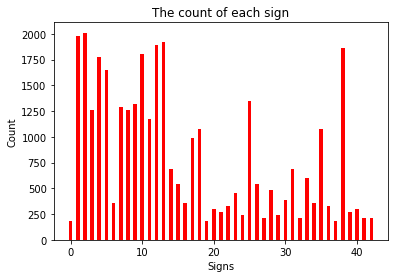

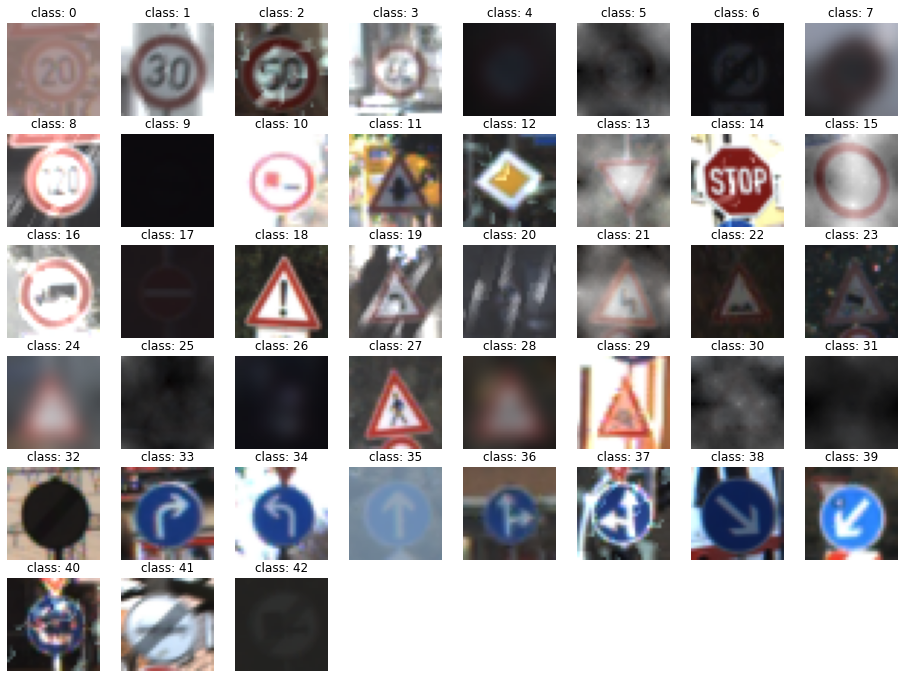

In [ ]:
### Data exploration visualization.
fig, ax = plt.subplots()
ax.bar(range(n_classes), np.bincount(Y_train), 0.5, color='r')
ax.set_xlabel('Signs')
ax.set_ylabel('Count')
ax.set_title('The count of each sign')
plt.show()

plt.figure(figsize=(16, 16))
for c in range(n_classes):
    i = random.choice(np.where(Y_train == c)[0])
    plt.subplot(8, 8, c+1)
    plt.axis('off')
    plt.title('class: {}'.format(c))
    plt.imshow(X_train[i])

In [ ]:
class BaselineNet(nn.Module):
    def __init__(self, gray=False):
        super(BaselineNet, self).__init__()
        input_chan = 1 if gray else 3
        self.conv1 = nn.Conv2d(input_chan, 6, 5)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(6, 16, 5)
        self.fc1 = nn.Linear(16 * 5 * 5, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 43)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(-1, 16 * 5 * 5)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

In [ ]:
torch.manual_seed(1)

In [ ]:
train_dataset = PickledDataset_training(training_file, transform=transforms.ToTensor())
valid_dataset = PickledDataset_validation(validation_file, transform=transforms.ToTensor())
test_dataset = PickledDataset_testing(testing_file, transform=transforms.ToTensor())

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=64, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

In [ ]:
model = BaselineNet()
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.001, momentum=0.9)
n_epochs = 20

In [ ]:
def loss_batch(model, loss_func, x, y, opt=None):
    loss = loss_func(model(x), y)
    
    if opt is not None:
        loss.backward()
        opt.step()
        opt.zero_grad()

    return loss.item(), len(x)
def valid_batch(model, loss_func, x, y):
    output = model(x)
    loss = loss_func(output, y)
    pred = torch.argmax(output, dim=1)
    correct = pred == y.view(*pred.shape)
    
    return loss.item(), torch.sum(correct).item(), len(x)
def fiit(epochs, model, loss_func, opt, train_dl, valid_dl, dl):
    for epoch in range(epochs):
        # Train model
        model.train()
        losses, nums = zip(*[loss_batch(model, loss_func, x, y, opt) for x, y in train_dl])
        train_loss = np.sum(np.multiply(losses, nums)) / np.sum(nums)
        # Validation model
        model.eval()
        with torch.no_grad():
            losses, corrects, nums = zip(*[valid_batch(model, loss_func, x, y) for x, y in valid_dl])
            valid_loss = np.sum(np.multiply(losses, nums)) / np.sum(nums)
            valid_accuracy = np.sum(corrects) / np.sum(nums) * 100
            losses, corrects, nums = zip(*[valid_batch(model, loss_func, x, y) for x, y in dl])
            test_loss = np.sum(np.multiply(losses, nums)) / np.sum(nums)
            test_accuracy = np.sum(corrects) / np.sum(nums) * 100
            print(f"[Epoch {epoch+1}/{epochs}] "
                  f"Test loss: {test_loss:.6f}\t"
                  f"Test accruacy: {test_accuracy:.3f}%"
                  f"Train loss: {train_loss:.6f}\t"
                  f"Validation loss: {valid_loss:.6f}\t",
                  f"Validation accruacy: {valid_accuracy:.3f}%")
def evaluate(model, loss_func, dl):
    model.eval()
    with torch.no_grad():
        losses, corrects, nums = zip(*[valid_batch(model, loss_func, x, y) for x, y in dl])
        test_loss = np.sum(np.multiply(losses, nums)) / np.sum(nums)
        test_accuracy = np.sum(corrects) / np.sum(nums) * 100
        
    print(f"Test loss: {test_loss:.6f}\t"
          f"Test accruacy: {test_accuracy:.3f}%")

In [ ]:
fiit(n_epochs, model, criterion, optimizer, train_loader, valid_loader, test_loader)
evaluate(model, criterion, test_loader)

[Epoch 1/20] Test loss: 3.505741	Test accruacy: 5.835%Train loss: 3.673265	Validation loss: 3.594732	 Validation accruacy: 5.465%
[Epoch 2/20] Test loss: 3.481505	Test accruacy: 6.516%Train loss: 3.490895	Validation loss: 3.571895	 Validation accruacy: 6.077%
[Epoch 3/20] Test loss: 3.467817	Test accruacy: 6.033%Train loss: 3.476097	Validation loss: 3.560757	 Validation accruacy: 6.395%
[Epoch 4/20] Test loss: 3.447911	Test accruacy: 8.306%Train loss: 3.458274	Validation loss: 3.536610	 Validation accruacy: 7.506%
[Epoch 5/20] Test loss: 3.358876	Test accruacy: 14.006%Train loss: 3.401951	Validation loss: 3.459590	 Validation accruacy: 13.832%
[Epoch 6/20] Test loss: 2.984755	Test accruacy: 19.715%Train loss: 3.160774	Validation loss: 3.050750	 Validation accruacy: 19.524%
[Epoch 7/20] Test loss: 2.520141	Test accruacy: 29.533%Train loss: 2.688806	Validation loss: 2.586547	 Validation accruacy: 28.073%
[Epoch 8/20] Test loss: 2.167336	Test accruacy: 39.438%Train loss: 2.236732	Validati

In [ ]:
with open('/content/drive/MyDrive/model_pickle1','wb') as f:
    pickle.dump(model,f)

In [ ]:
import pickle
with open('/content/drive/MyDrive/model_pickle1','rb') as f:
    M1 = pickle.load(f)

In [ ]:
# Load pickled data
training_pickled_gray = "/content/drive/MyDrive/GTSRB/train_gray.p"

with open(training_pickled_gray, mode='rb') as f:
    train_gray = pickle.load(f)

x_train_gray, y_train_gray = train_gray['features'], train_gray['labels']

sometimes = lambda aug: iaa.Sometimes(0.5, aug)
# Pipeline:
# (1) Crop images from each side by 1-16px, do not resize the results
#     images back to the input size. Keep them at the cropped size.
# (2) Horizontally flip 50% of the images.
# (3) Blur images using a gaussian kernel with sigma between 0.0 and 3.0.
seq = iaa.Sequential(
    [
           
            iaa.OneOf(
                [
                    sometimes(
                                         iaa.imgcorruptlike.GaussianBlur(severity=3)
                             ),
                    
                    sometimes(
                                         iaa.imgcorruptlike.Fog(severity=3)
                             ),
                    
                    sometimes(
                                         iaa.imgcorruptlike.Snow(severity=3)
                             ),
                    
                    sometimes(
                                         iaa.imgcorruptlike.Spatter(severity=3)
                             ),
                    
                    sometimes(
                                         iaa.imgcorruptlike.Contrast(severity=3)
                             ),
                ]
            )
             
        ]
    )
x_train_gray_aug = seq(images=x_train_gray)  # done by the library

distorted_train_gray = {
        "x_train_gray_distorted": x_train_gray_aug,
        "y_train_gray": y_train_gray,
        
    }
pickle.dump(distorted_train_gray, open("distorted_train_gray.p", "wb"))

In [ ]:
# Load pickled data
testing_pickled_gray = "/content/drive/MyDrive/GTSRB/test_gray.p"

with open(testing_pickled_gray, mode='rb') as f:
    test_gray = pickle.load(f)

x_test_gray, y_test_gray = test_gray['features'], test_gray['labels']

sometimes = lambda aug: iaa.Sometimes(0.5, aug)
# Pipeline:
# (1) Crop images from each side by 1-16px, do not resize the results
#     images back to the input size. Keep them at the cropped size.
# (2) Horizontally flip 50% of the images.
# (3) Blur images using a gaussian kernel with sigma between 0.0 and 3.0.
seq = iaa.Sequential(
    [
           
            iaa.OneOf(
                [
                    sometimes(
                                         iaa.imgcorruptlike.GaussianBlur(severity=3)
                             ),
                    
                    sometimes(
                                         iaa.imgcorruptlike.Fog(severity=3)
                             ),
                    
                    sometimes(
                                         iaa.imgcorruptlike.Snow(severity=3)
                             ),
                    
                    sometimes(
                                         iaa.imgcorruptlike.Spatter(severity=3)
                             ),
                    
                    sometimes(
                                         iaa.imgcorruptlike.Contrast(severity=3)
                             ),
                ]
            )
             
        ]
    )
x_test_gray_aug = seq(images=x_test_gray)  # done by the library

distorted_test_gray = {
        "x_test_gray_distorted": x_test_gray_aug,
        "y_test_gray": y_test,
        
    }
pickle.dump(distorted_test_gray, open("distorted_test_gray.p", "wb"))

In [ ]:
# Load pickled data
validation_pickled = "/content/drive/MyDrive/GTSRB/valid_gray.p"

with open(validation_pickled, mode='rb') as f:
    valid_gray = pickle.load(f)

x_valid_gray, y_valid_gray = valid_gray['features'], valid_gray['labels']

sometimes = lambda aug: iaa.Sometimes(0.5, aug)
# Pipeline:
# (1) Crop images from each side by 1-16px, do not resize the results
#     images back to the input size. Keep them at the cropped size.
# (2) Horizontally flip 50% of the images.
# (3) Blur images using a gaussian kernel with sigma between 0.0 and 3.0.
seq = iaa.Sequential(
    [
           
            iaa.OneOf(
                [
                    sometimes(
                                         iaa.imgcorruptlike.GaussianBlur(severity=3)
                             ),
                    
                    sometimes(
                                         iaa.imgcorruptlike.Fog(severity=3)
                             ),
                    
                    sometimes(
                                         iaa.imgcorruptlike.Snow(severity=3)
                             ),
                    
                    sometimes(
                                         iaa.imgcorruptlike.Spatter(severity=3)
                             ),
                    
                    sometimes(
                                         iaa.imgcorruptlike.Contrast(severity=3)
                             ),
                ]
            )
             
        ]
    )
x_valid_gray_aug = seq(images=x_valid_gray)  # done by the library

distorted_valid_gray = {
        "x_valid_gray_distorted": x_valid_gray_aug,
        "y_valid_gray": y_valid_gray,
        
    }
pickle.dump(distorted_valid_gray, open("distorted_valid_gray.p", "wb"))

In [ ]:
# Load gray distorted data
training_file_gray="distorted_train_gray.p"
testing_file_gray="distorted_test_gray.p"
validation_file_gray="distorted_valid_gray.p"


with open(training_file_gray, mode='rb') as f:
    train_gray_d = pickle.load(f)
with open(validation_file_gray, mode='rb') as f:
    valid_gray_d = pickle.load(f)
with open(testing_file_gray, mode='rb') as f:
    test_gray_d = pickle.load(f)

X_train_gray, Y_train_gray = train_gray_d['x_train_gray_distorted'], train_gray_d['y_train_gray']
X_valid_gray, Y_valid_gray = valid_gray_d['x_valid_gray_distorted'], valid_gray_d['y_valid_gray']
X_test_gray, Y_test_gray = test_gray_d['x_test_gray_distorted'], test_gray_d['y_test_gray']

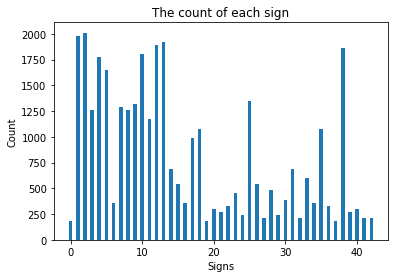

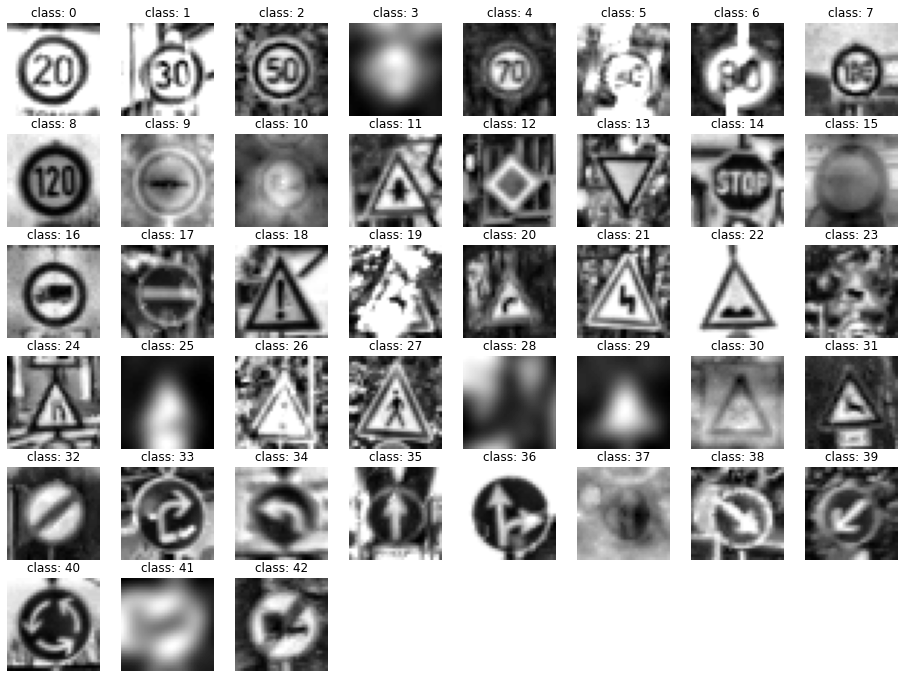

In [ ]:
### Data exploration visualization.
fig, ax = plt.subplots()
ax.bar(range(n_classes), np.bincount(Y_train_gray), 0.5)
ax.set_xlabel('Signs')
ax.set_ylabel('Count')
ax.set_title('The count of each sign')
plt.show()

plt.figure(figsize=(16, 16))
for c in range(n_classes):
    i = random.choice(np.where(Y_train_gray == c)[0])
    plt.subplot(8, 8, c+1)
    plt.axis('off')
    plt.title('class: {}'.format(c))
    plt.imshow(X_train_gray[i], cmap='gray')

In [ ]:
class PickledDataset_training_gray(Dataset):
    def __init__(self, file_path, transform=None):
        with open(file_path, mode='rb') as f:
            data = pickle.load(f)
            self.feature = data['x_train_gray_distorted']
            self.label = data['y_train_gray']
            self.count = len(self.label)
            self.transform = transform
        
    def __getitem__(self, index):
        feature = self.feature[index]
        if self.transform is not None:
            feature = self.transform(feature)
        return (feature, self.label[index])

    def __len__(self):
        return self.count

In [ ]:
class PickledDataset_testing_gray(Dataset):
    def __init__(self, file_path, transform=None):
        with open(file_path, mode='rb') as f:
            data = pickle.load(f)
            self.feature = data['x_test_gray_distorted']
            self.label = data['y_test_gray']
            self.count = len(self.label)
            self.transform = transform
        
    def __getitem__(self, index):
        feature = self.feature[index]
        if self.transform is not None:
            feature = self.transform(feature)
        return (feature, self.label[index])

    def __len__(self):
        return self.count

In [ ]:
class PickledDataset_validation_gray(Dataset):
    def __init__(self, file_path, transform=None):
        with open(file_path, mode='rb') as f:
            data = pickle.load(f)
            self.feature = data['x_valid_gray_distorted']
            self.label = data['y_valid_gray']
            self.count = len(self.label)
            self.transform = transform
        
    def __getitem__(self, index):
        feature = self.feature[index]
        if self.transform is not None:
            feature = self.transform(feature)
        return (feature, self.label[index])

    def __len__(self):
        return self.count

In [ ]:
train_dataset_gray = PickledDataset_training_gray(training_file_gray, transform=transforms.ToTensor())
valid_dataset_gray = PickledDataset_validation_gray(validation_file_gray, transform=transforms.ToTensor())
test_dataset_gray = PickledDataset_testing_gray(testing_file_gray, transform=transforms.ToTensor())

train_loader_gray = DataLoader(train_dataset_gray, batch_size=64, shuffle=True)
valid_loader_gray = DataLoader(valid_dataset_gray, batch_size=64, shuffle=False)
test_loader_gray = DataLoader(test_dataset_gray, batch_size=64, shuffle=False)

In [ ]:
model = BaselineNet(gray=True)
optimizer = optim.SGD(model.parameters(), lr=0.001, momentum=0.9)
fiit(n_epochs, model, criterion, optimizer, train_loader_gray, valid_loader_gray, test_loader_gray)
evaluate(model, criterion, test_loader_gray)

[Epoch 1/20] Test loss: 3.491912	Test accruacy: 5.115%Train loss: 3.684703	Validation loss: 3.572103	 Validation accruacy: 5.420%
[Epoch 2/20] Test loss: 3.467819	Test accruacy: 5.701%Train loss: 3.483149	Validation loss: 3.565690	 Validation accruacy: 5.442%
[Epoch 3/20] Test loss: 3.458973	Test accruacy: 5.962%Train loss: 3.473387	Validation loss: 3.548484	 Validation accruacy: 5.420%
[Epoch 4/20] Test loss: 3.434962	Test accruacy: 10.562%Train loss: 3.457740	Validation loss: 3.528123	 Validation accruacy: 11.134%
[Epoch 5/20] Test loss: 3.279254	Test accruacy: 16.793%Train loss: 3.379993	Validation loss: 3.361849	 Validation accruacy: 15.465%
[Epoch 6/20] Test loss: 2.771452	Test accruacy: 27.173%Train loss: 2.994738	Validation loss: 2.838866	 Validation accruacy: 26.122%
[Epoch 7/20] Test loss: 2.220903	Test accruacy: 39.438%Train loss: 2.338565	Validation loss: 2.229099	 Validation accruacy: 40.975%
[Epoch 8/20] Test loss: 1.829545	Test accruacy: 50.523%Train loss: 1.833393	Valida

In [ ]:
import pickle
with open('/content/drive/MyDrive/model_pickle2','wb') as f:
    pickle.dump(model,f)

In [ ]:
import pickle
with open('/content/drive/MyDrive/model_pickle2','rb') as f:
    M2 = pickle.load(f)

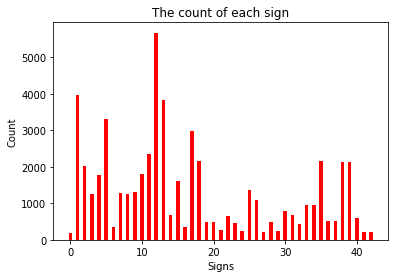

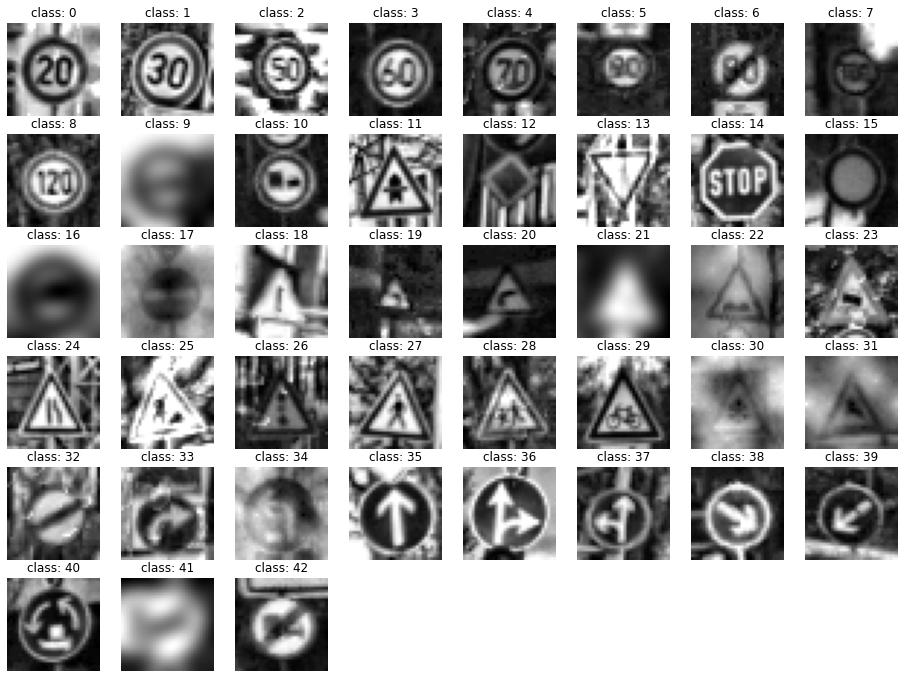

In [ ]:
def extend_dataset(dataset):
    X = dataset.feature
    y = dataset.label
    num_classes = 43
    
    X_extended = np.empty([0] + list(dataset.feature.shape)[1:], dtype=dataset.feature.dtype)
    y_extended = np.empty([0], dtype = dataset.label.dtype)
    
    horizontally_flippable = [11, 12, 13, 15, 17, 18, 22, 26, 30, 35]
    vertically_flippable = [1, 5, 12, 15, 17]
    both_flippable = [32, 40]
    cross_flippable = np.array([
        [19, 20],
        [33, 34],
        [36, 37],
        [38, 39],
        [20, 19],
        [34, 33],
        [37, 36],
        [39, 38]
    ])
    
    for c in range(num_classes):
        X_extended = np.append(X_extended, X[y==c], axis=0)  
        
        if c in horizontally_flippable:
            X_extended = np.append(X_extended, X[y==c][:,:,::-1,:], axis=0)
        if c in vertically_flippable:
            X_extended = np.append(X_extended, X[y==c][:,::-1,:,:], axis=0)
        if c in cross_flippable[:,0]:
            flip_c = cross_flippable[cross_flippable[:,0]==c][0][1]
            X_extended = np.append(X_extended, X[y==flip_c][:,:,::-1,:], axis=0)
        if c in both_flippable:
            X_extended = np.append(X_extended, X[y==c][:,::-1,::-1,:], axis=0)
        
        y_extended = np.append(y_extended, np.full(X_extended.shape[0]-y_extended.shape[0], c, dtype=y_extended.dtype))
    
    dataset.feature = X_extended
    dataset.label = y_extended
    dataset.count = len(y_extended)
    
    return dataset
train_dataset_gray = extend_dataset(train_dataset_gray)
train_loader_gray = DataLoader(train_dataset_gray, batch_size=64, shuffle=True)
### Data exploration visualization.
fig, ax = plt.subplots()
ax.bar(range(n_classes), np.bincount(train_dataset_gray.label), 0.5, color='r')
ax.set_xlabel('Signs')
ax.set_ylabel('Count')
ax.set_title('The count of each sign')
plt.show()

plt.figure(figsize=(16, 16))
for c in range(n_classes):
    i = random.choice(np.where(train_dataset_gray.label == c)[0])
    plt.subplot(8, 8, c+1)
    plt.axis('off')
    plt.title('class: {}'.format(c))
    plt.imshow(train_dataset_gray.feature[i].squeeze(), cmap='gray')

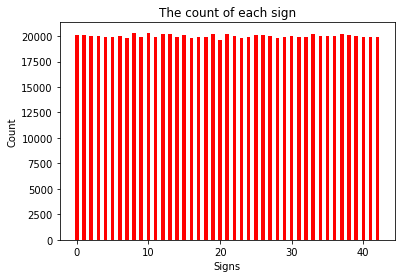

In [ ]:
train_dataset_gray = extend_dataset(PickledDataset_training_gray(training_file_gray))

class_sample_count = np.bincount(train_dataset_gray.label)
weights = 1 / np.array([class_sample_count[y] for y in train_dataset_gray.label])
samp = sampler.WeightedRandomSampler(weights, 43 * 20000)

train_loader_gray = DataLoader(train_dataset_gray, batch_size=64, sampler=samp)
balanced_Y_train_gray = torch.LongTensor([])

with torch.no_grad():
    for _, y in train_loader_gray:
        balanced_Y_train_gray = torch.cat((balanced_Y_train_gray, y))

fig, ax = plt.subplots()
ax.bar(range(n_classes), np.bincount( balanced_Y_train_gray.cpu().numpy()), 0.5, color='r')
ax.set_xlabel('Signs')
ax.set_ylabel('Count')
ax.set_title('The count of each sign')
plt.show()

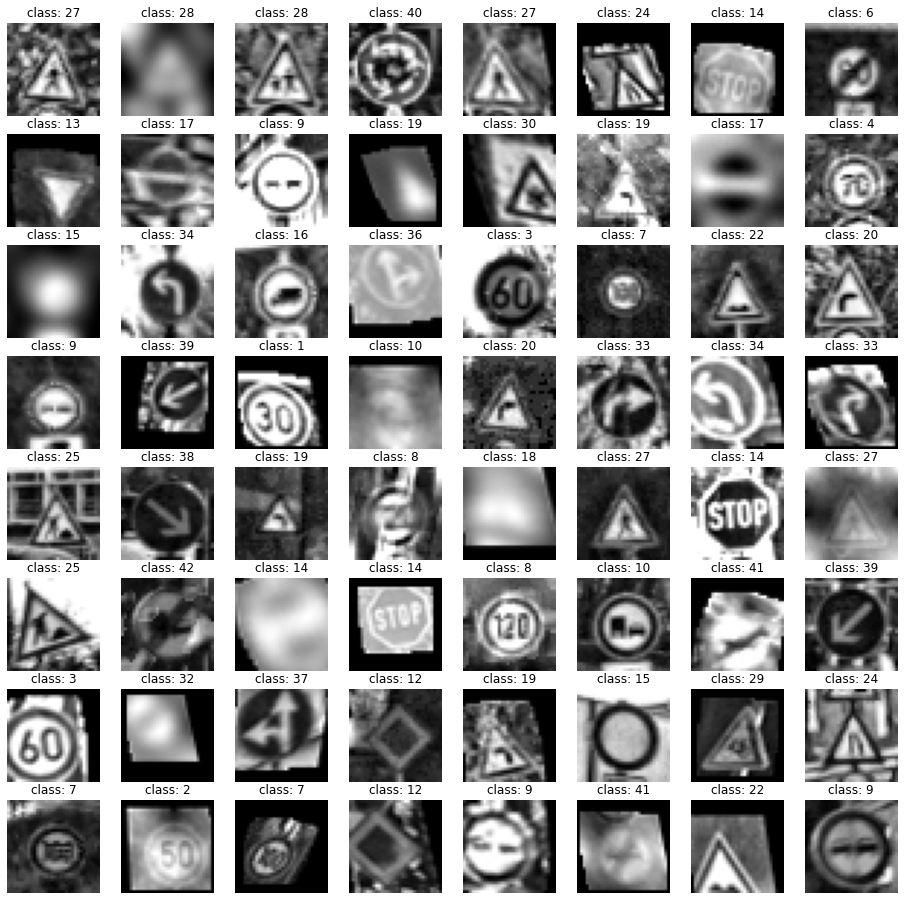

In [ ]:

train_data_transforms = transforms.Compose([
    transforms.ToPILImage(),
    transforms.RandomApply([
        transforms.RandomRotation(20, resample=PIL.Image.BICUBIC),
        transforms.RandomAffine(0, translate=(0.2, 0.2), resample=PIL.Image.BICUBIC),
        transforms.RandomAffine(0, shear=20, resample=PIL.Image.BICUBIC),
        transforms.RandomAffine(0, scale=(0.8, 1.2), resample=PIL.Image.BICUBIC)
    ]),
    transforms.ToTensor()
])
test_data_transforms = transforms.ToTensor()

train_dataset_gray = extend_dataset(PickledDataset_training_gray(training_file_gray, transform=train_data_transforms))
valid_dataset_gray = PickledDataset_validation_gray(validation_file_gray, transform=test_data_transforms)
test_dataset_gray = PickledDataset_testing_gray(testing_file_gray, transform=test_data_transforms)

train_loader_gray = DataLoader(train_dataset_gray, batch_size=64, sampler=samp)
valid_loader_gray = DataLoader(valid_dataset_gray, batch_size=64, shuffle=False)
test_loader_gray = DataLoader(test_dataset_gray, batch_size=64, shuffle=False)

def convert_image_np(img):
    img = img.numpy().transpose((1, 2, 0)).squeeze()
    return img
with torch.no_grad():
    x, y = next(iter(train_loader_gray))
    plt.figure(figsize=(16, 16))
    for i in range(len(y)):
        plt.subplot(8, 8, i+1)
        plt.axis('off')
        plt.title('class: {}'.format(y[i]))
        plt.imshow(convert_image_np(x[i].cpu()), cmap='gray')

In [ ]:
model = BaselineNet(gray=True)
optimizer = optim.SGD(model.parameters(), lr=0.001, momentum=0.9)
fiit(n_epochs, model, criterion, optimizer, train_loader_gray, valid_loader_gray, test_loader_gray)
evaluate(model, criterion, test_loader_gray)

[Epoch 1/20] Test loss: 2.865393	Test accruacy: 23.713%Train loss: 3.573633	Validation loss: 2.878902	 Validation accruacy: 23.583%
[Epoch 2/20] Test loss: 2.061723	Test accruacy: 43.785%Train loss: 2.583475	Validation loss: 2.045968	 Validation accruacy: 45.238%
[Epoch 3/20] Test loss: 1.859217	Test accruacy: 49.897%Train loss: 2.108259	Validation loss: 1.862444	 Validation accruacy: 50.499%
[Epoch 4/20] Test loss: 1.769582	Test accruacy: 52.629%Train loss: 1.919039	Validation loss: 1.781904	 Validation accruacy: 52.880%
[Epoch 5/20] Test loss: 1.757874	Test accruacy: 52.914%Train loss: 1.816980	Validation loss: 1.727218	 Validation accruacy: 53.741%
[Epoch 6/20] Test loss: 1.782143	Test accruacy: 52.391%Train loss: 1.756899	Validation loss: 1.735926	 Validation accruacy: 53.673%
[Epoch 7/20] Test loss: 1.751586	Test accruacy: 54.038%Train loss: 1.710638	Validation loss: 1.789087	 Validation accruacy: 53.492%
[Epoch 8/20] Test loss: 1.713321	Test accruacy: 54.014%Train loss: 1.676298	

In [ ]:
evaluate(model, criterion, test_loader_gray)

Test loss: 1.342516	Test accruacy: 64.046%


In [ ]:
with open('model_pickle3','wb') as f:
    pickle.dump(model,f)

In [ ]:
import pickle
with open('model_pickle3','rb') as f:
    M3 = pickle.load(f)

FileNotFoundError: [Errno 2] No such file or directory: 'model_pickle3'

In [ ]:
class TrafficSignNet(nn.Module):
    def __init__(self):
        super(TrafficSignNet, self).__init__()
        self.conv1 = nn.Conv2d(1, 100, 5)
        self.conv1_bn = nn.BatchNorm2d(100)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(100, 150, 3)
        self.conv2_bn = nn.BatchNorm2d(150)
        self.conv3 = nn.Conv2d(150, 250, 1)
        self.conv3_bn = nn.BatchNorm2d(250)
        self.fc1 = nn.Linear(250 * 3 * 3, 350)
        self.fc1_bn = nn.BatchNorm1d(350)
        self.fc2 = nn.Linear(350, 43)
        self.dropout = nn.Dropout(p=0.5)

    def forward(self, x):
        x = self.pool(F.elu(self.conv1(x)))
        x = self.dropout(self.conv1_bn(x))
        x = self.pool(F.elu(self.conv2(x)))
        x = self.dropout(self.conv2_bn(x))
        x = self.pool(F.elu(self.conv3(x)))
        x = self.dropout(self.conv3_bn(x))
        x = x.view(-1, 250 * 3 * 3)
        x = F.elu(self.fc1(x))
        x = self.dropout(self.fc1_bn(x))
        x = self.fc2(x)
        return x
def fit(epochs, model, loss_func, opt, train_dl, valid_dl, patience=10):
    wait = 0
    valid_loss_min = np.Inf
    for epoch in range(epochs):
        # Train model
        model.train()
        losses, nums = zip(*[loss_batch(model, loss_func, x, y, opt) for x, y in train_dl])
        train_loss = np.sum(np.multiply(losses, nums)) / np.sum(nums)
        # Validation model
        model.eval()
        with torch.no_grad():
            losses, corrects, nums = zip(*[valid_batch(model, loss_func, x, y) for x, y in valid_dl])
            valid_loss = np.sum(np.multiply(losses, nums)) / np.sum(nums)
            valid_accuracy = np.sum(corrects) / np.sum(nums) * 100
            print(f"[Epoch {epoch+1}/{epochs}] "
                  f"Train loss: {train_loss:.6f}\t"
                  f"Validation loss: {valid_loss:.6f}\t",
                  f"Validation accruacy: {valid_accuracy:.3f}%")
            # Save model if validation loss has decreased
            if valid_loss <= valid_loss_min:
                print(f"Validation loss decreased ({valid_loss_min:.6f} --> {valid_loss:.6f}). Saving model...")
                torch.save(model.state_dict(), 'model.pt')
                valid_loss_min = valid_loss
                wait = 0
            # Early stopping
            else:
                wait += 1
                if wait >= patience:
                    print(f"Terminated Training for Early Stopping at Epoch {epoch+1}")
                    return

In [ ]:
n_epochs = 75
model = TrafficSignNet()
optimizer = optim.Adam(model.parameters(), lr=0.001)
fiit(n_epochs, model, criterion, optimizer, train_loader_gray, valid_loader_gray,test_loader_gray)

[Epoch 1/75] Test loss: 1.698125	Test accruacy: 55.891%Train loss: 2.208488	Validation loss: 1.701602	 Validation accruacy: 56.803%
[Epoch 2/75] Test loss: 1.526464	Test accruacy: 59.343%Train loss: 1.875348	Validation loss: 1.522739	 Validation accruacy: 59.796%
[Epoch 3/75] Test loss: 1.491887	Test accruacy: 60.491%Train loss: 1.777687	Validation loss: 1.503306	 Validation accruacy: 61.293%
[Epoch 4/75] Test loss: 1.467343	Test accruacy: 61.401%Train loss: 1.724843	Validation loss: 1.467900	 Validation accruacy: 62.177%
[Epoch 5/75] Test loss: 1.410687	Test accruacy: 61.948%Train loss: 1.684117	Validation loss: 1.411737	 Validation accruacy: 62.789%
[Epoch 6/75] Test loss: 1.421186	Test accruacy: 61.758%Train loss: 1.658541	Validation loss: 1.427317	 Validation accruacy: 62.245%
[Epoch 7/75] Test loss: 1.401418	Test accruacy: 62.272%Train loss: 1.637349	Validation loss: 1.409978	 Validation accruacy: 62.744%
[Epoch 8/75] Test loss: 1.405808	Test accruacy: 62.486%Train loss: 1.623944	

[Epoch 63/75] Test loss: 1.343895	Test accruacy: 64.315%Train loss: 1.481328	Validation loss: 1.373910	 Validation accruacy: 64.172%
[Epoch 64/75] Test loss: 1.341006	Test accruacy: 64.181%Train loss: 1.475134	Validation loss: 1.366283	 Validation accruacy: 64.308%
[Epoch 65/75] Test loss: 1.320414	Test accruacy: 65.614%Train loss: 1.476444	Validation loss: 1.349226	 Validation accruacy: 65.442%
[Epoch 66/75] Test loss: 1.338500	Test accruacy: 65.629%Train loss: 1.476412	Validation loss: 1.362486	 Validation accruacy: 65.556%
[Epoch 67/75] Test loss: 1.344868	Test accruacy: 64.165%Train loss: 1.475954	Validation loss: 1.359865	 Validation accruacy: 64.331%
[Epoch 68/75] Test loss: 1.315800	Test accruacy: 65.693%Train loss: 1.476313	Validation loss: 1.342628	 Validation accruacy: 65.397%
[Epoch 69/75] Test loss: 1.329693	Test accruacy: 65.471%Train loss: 1.473243	Validation loss: 1.354134	 Validation accruacy: 65.556%
[Epoch 70/75] Test loss: 1.323035	Test accruacy: 65.709%Train loss: 1

In [ ]:
with open('model_pickle4','wb') as f:
    pickle.dump(model,f)

In [ ]:
import pickle
with open('model_pickle4','rb') as f:
    mp = pickle.load(f)

In [ ]:
class Stn(nn.Module):
    def __init__(self):
        super(Stn, self).__init__()
        # Spatial transformer localization-network
        self.loc_net = nn.Sequential(
            nn.Conv2d(1, 50, 7),
            nn.MaxPool2d(2, 2),
            nn.ELU(),
            nn.Conv2d(50, 100, 5),
            nn.MaxPool2d(2, 2),
            nn.ELU()
        )
        # Regressor for the 3 * 2 affine matrix
        self.fc_loc = nn.Sequential(
            nn.Linear(100 * 4 * 4, 100),
            nn.ELU(),
            nn.Linear(100, 3 * 2)
        )
        # Initialize the weights/bias with identity transformation
        self.fc_loc[2].weight.data.zero_()
        self.fc_loc[2].bias.data.copy_(torch.tensor([1, 0, 0, 0, 1, 0], dtype=torch.float))
        
    def forward(self, x):
        xs = self.loc_net(x)
        xs = xs.view(-1, 100 * 4 * 4)
        theta = self.fc_loc(xs)
        theta = theta.view(-1, 2, 3)

        grid = F.affine_grid(theta, x.size())
        x = F.grid_sample(x, grid)

        return x
class TrafficSignNet(nn.Module):
    def __init__(self):
        super(TrafficSignNet, self).__init__()
        self.stn = Stn()
        self.conv1 = nn.Conv2d(1, 100, 5)
        self.conv1_bn = nn.BatchNorm2d(100)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(100, 150, 3)
        self.conv2_bn = nn.BatchNorm2d(150)
        self.conv3 = nn.Conv2d(150, 250, 1)
        self.conv3_bn = nn.BatchNorm2d(250)
        self.fc1 = nn.Linear(250 * 3 * 3, 350)
        self.fc1_bn = nn.BatchNorm1d(350)
        self.fc2 = nn.Linear(350, 43)
        self.dropout = nn.Dropout(p=0.5)

    def forward(self, x):
        x = self.stn(x)
        x = self.pool(F.elu(self.conv1(x)))
        x = self.dropout(self.conv1_bn(x))
        x = self.pool(F.elu(self.conv2(x)))
        x = self.dropout(self.conv2_bn(x))
        x = self.pool(F.elu(self.conv3(x)))
        x = self.dropout(self.conv3_bn(x))
        x = x.view(-1, 250 * 3 * 3)
        x = F.elu(self.fc1(x))
        x = self.dropout(self.fc1_bn(x))
        x = self.fc2(x)
        return x

In [ ]:
n_epochs=20
model = TrafficSignNet()
optimizer = optim.Adam(model.parameters(), lr=0.0001)
fiit(n_epochs, model, criterion, optimizer, train_loader_gray, valid_loader_gray,test_loader_gray)

[Epoch 1/20] Test loss: 0.069874	Test accruacy: 97.838%Train loss: 0.474795	Validation loss: 0.084702	 Validation accruacy: 98.050%
[Epoch 2/20] Test loss: 0.048681	Test accruacy: 98.575%Train loss: 0.078650	Validation loss: 0.068684	 Validation accruacy: 98.345%
[Epoch 3/20] Test loss: 0.033374	Test accruacy: 99.169%Train loss: 0.050938	Validation loss: 0.038911	 Validation accruacy: 98.776%
[Epoch 4/20] Test loss: 0.034428	Test accruacy: 99.082%Train loss: 0.039206	Validation loss: 0.049903	 Validation accruacy: 98.639%
[Epoch 5/20] Test loss: 0.036612	Test accruacy: 98.971%Train loss: 0.033809	Validation loss: 0.048766	 Validation accruacy: 98.639%
[Epoch 6/20] Test loss: 0.031348	Test accruacy: 99.042%Train loss: 0.029882	Validation loss: 0.052945	 Validation accruacy: 98.730%
[Epoch 7/20] Test loss: 0.030103	Test accruacy: 99.208%Train loss: 0.026611	Validation loss: 0.035044	 Validation accruacy: 98.821%
[Epoch 8/20] Test loss: 0.034637	Test accruacy: 99.018%Train loss: 0.024183	

In [ ]:
evaluate(model, criterion, test_loader)

Test loss: 0.034067	Test accruacy: 99.200%


In [ ]:
with open('model_pickle5','wb') as f:
    pickle.dump(model,f)

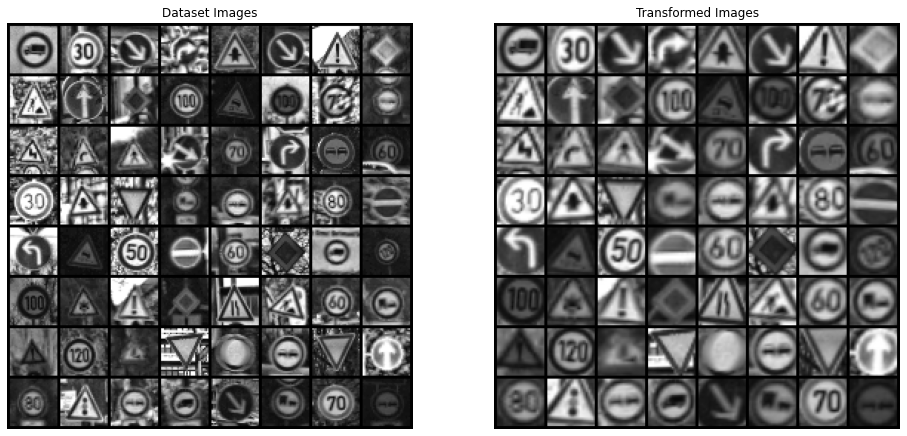

In [ ]:
def visualize_stn():
    with torch.no_grad():
        data = next(iter(test_loader))[0]

        input_tensor = data.cpu()
        transformed_tensor = model.stn(data).cpu()

        input_grid = convert_image_np(make_grid(input_tensor))
        transformed_grid = convert_image_np(make_grid(transformed_tensor))

        # Plot the results side-by-side
        fig, ax = plt.subplots(1, 2)
        fig.set_size_inches((16, 16))
        ax[0].imshow(input_grid)
        ax[0].set_title('Dataset Images')
        ax[0].axis('off')

        ax[1].imshow(transformed_grid)
        ax[1].set_title('Transformed Images')
        ax[1].axis('off')
        
visualize_stn()